--- Data Loaded Successfully ---
Shape of Dataset: (10143, 7)

--- Data Types ---
Date             str
Adj_Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

--- Summary Statistics ---
              Date     Adj_Close         Close          High           Low  \
count        10143  10143.000000  10143.000000  10143.000000  10143.000000   
unique       10143           NaN           NaN           NaN           NaN   
top     1986-03-13           NaN           NaN           NaN           NaN   
freq             1           NaN           NaN           NaN           NaN   
mean           NaN     69.989506     76.273102     77.017792     75.475608   
std            NaN    119.464685    119.981232    121.046756    118.829505   
min            NaN      0.054902      0.090278      0.092014      0.088542   
25%            NaN      3.895945      6.406250      6.472656      6.316406   
50%            NaN     19.5

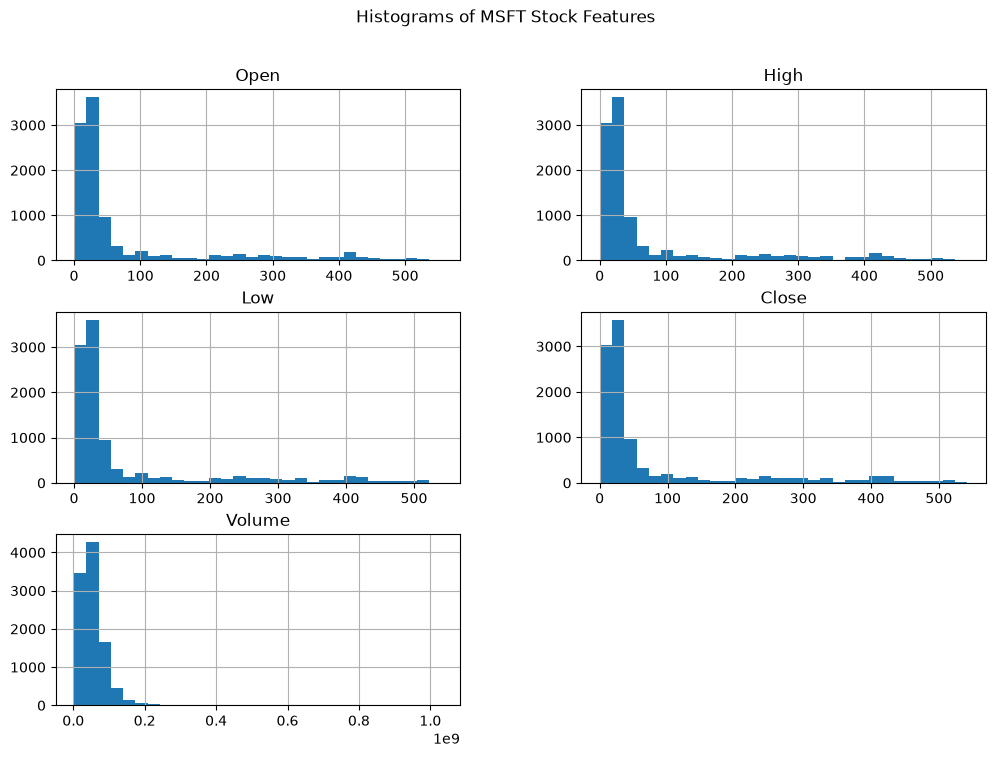

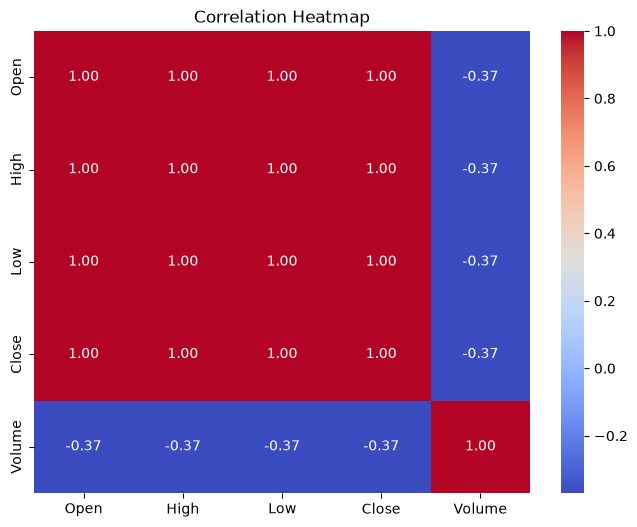

Mean of Volume: 55304769.20
Median of Volume: 48478400.00


C:\Users\l3eam\AppData\Local\Temp\ipykernel_24132\3852970286.py:66: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Volume'], label='Original Volume', shade=True)


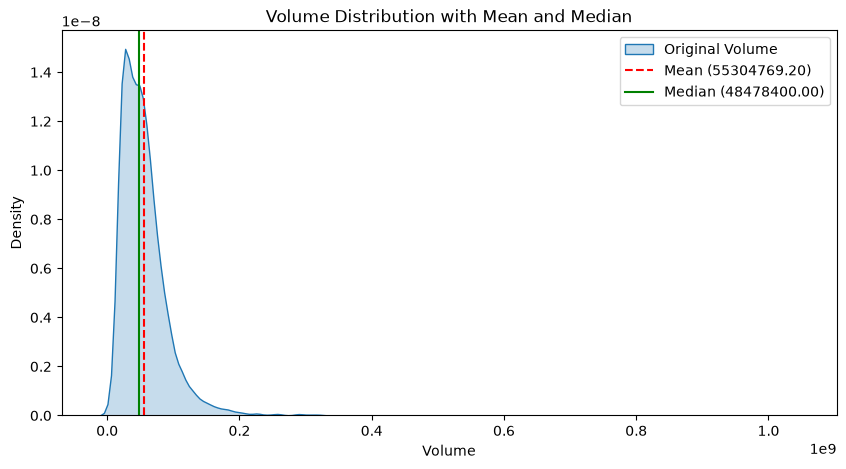


--- Final Head of Processed MSFT Dataset ---
        Date  Adj_Close     Close      High       Low      Open      Volume  \
0 1986-03-13   0.059125  0.097222  0.101563  0.088542  0.088542  1031788800   
1 1986-03-14   0.061237  0.100694  0.102431  0.097222  0.097222   308160000   
2 1986-03-17   0.062293  0.102431  0.103299  0.100694  0.100694   133171200   
3 1986-03-18   0.060709  0.099826  0.103299  0.098958  0.102431    67766400   
4 1986-03-19   0.059653  0.098090  0.100694  0.097222  0.099826    47894400   

   Price_Direction Month_Name  Month_Encoded  Quarter_Q2  Quarter_Q3  \
0                1      March              7       False       False   
1                1      March              7       False       False   
2                1      March              7       False       False   
3                0      March              7       False       False   
4                0      March              7       False       False   

   Quarter_Q4  Open_Scaled  Close_Scaled  
0  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- LAB1: Dataset Exploration ---
# 1. Load Dataset (ปรับให้ตรงกับชื่อไฟล์ของคุณแล้ว)
df = pd.read_csv('MSFT_price.csv')
print("--- Data Loaded Successfully ---")

# 2. Display Shape
print(f"Shape of Dataset: {df.shape}")

# 3. Display Data Types
print("\n--- Data Types ---")
print(df.dtypes)

# 4. Display Summary Statistics
print("\n--- Summary Statistics ---")
print(df.describe(include='all'))

# 5. Display Missing Values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 6. Display Duplicate Records
print(f"\nNumber of Duplicate Records: {df.duplicated().sum()}")

# 7. Display Class Distribution (สร้างคลาสจำลองเพื่อดูทิศทางหุ้น ขึ้น=1, ลง/เท่าเดิม=0)
df['Price_Direction'] = np.where(df['Close'] > df['Open'], 1, 0)
print("\n--- Class Distribution (Price Direction) ---")
print(df['Price_Direction'].value_counts(normalize=True))


# --- LAB2: Data Visualization ---
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
# 1. Histogram
df[numeric_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Histograms of MSFT Stock Features")
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# --- Part 3: Data Cleaning ---
# 1. Data Type Conversion (แปลง Date เป็นรูปแบบวันที่ที่ถูกต้อง)
df['Date'] = pd.to_datetime(df['Date'])

# 2. Duplicate Removal
df.drop_duplicates(inplace=True)

# 3. Compare Mean vs Median ของ Volume
vol_mean = df['Volume'].mean()
vol_median = df['Volume'].median()
print(f"Mean of Volume: {vol_mean:.2f}")
print(f"Median of Volume: {vol_median:.2f}")

# พล็อตเปรียบเทียบการกระจายตัว
plt.figure(figsize=(10, 5))
sns.kdeplot(df['Volume'], label='Original Volume', shade=True)
plt.axvline(vol_mean, color='r', linestyle='--', label=f'Mean ({vol_mean:.2f})')
plt.axvline(vol_median, color='g', linestyle='-', label=f'Median ({vol_median:.2f})')
plt.title("Volume Distribution with Mean and Median")
plt.legend()
plt.show()


# --- Part 4: Feature Engineering ---
df_encoded = df.copy()

# 1. Label Encoding (สกัดเดือนออกมาแล้วเปลี่ยนเป็นตัวเลขกลุ่ม)
df_encoded['Month_Name'] = df_encoded['Date'].dt.strftime('%B')
le = LabelEncoder()
df_encoded['Month_Encoded'] = le.fit_transform(df_encoded['Month_Name'])

# 2. One-Hot Encoding (สกัดไตรมาสออกมาทำ One-Hot)
df_encoded['Quarter'] = 'Q' + df_encoded['Date'].dt.quarter.astype(str)
df_encoded = pd.get_dummies(df_encoded, columns=['Quarter'], drop_first=True)

# 3. Feature Scaling (ปรับสเกลราคา Open และ Close)
scaler = StandardScaler()
df_encoded[['Open_Scaled', 'Close_Scaled']] = scaler.fit_transform(df_encoded[['Open', 'Close']])

print("\n--- Final Head of Processed MSFT Dataset ---")
print(df_encoded.head())